IEEE-CIS Fraud Detection - LinearRegression

0. Setup

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn mlflow
import os, gc, time, pickle, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.feature_selection import (mutual_info_classif, VarianceThreshold,
                                       SelectKBest, RFE)
from sklearn.inspection import permutation_importance

import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 82.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 69.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 9.0 MB/s eta 0:00:00


In [4]:
!pip install dagshub
import dagshub
REPO_OWNER = "rkvit23"
REPO_NAME  = "ML-HW2"
dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/rkvit23/ML-HW2.mlflow")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: dacite
    Found existing installation: dacite 1.9.2
    Uninstalling dacite-1.9.2:
      Successfully uninstalled dacite-1.9.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires dacite<2,>=1.9, but you have dacite 1.6.0 which is incompatible.


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=2f30078a-7790-4b80-833a-75325245b3cc&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=3ba33150194186cd652a82f38ece7db8f1081fbd528adb13ce96edd181ff144f




Accessing as rkvit23

Initialized MLflow to track repo "rkvit23/ML-HW2"

Repository rkvit23/ML-HW2 initialized!

In [49]:
MODEL_TAG = 'LinearRegression'
MLFLOW_EXPERIMENT = 'LinearRegressionTraining'
print('MLflow experiment:', MLFLOW_EXPERIMENT)

MLflow experiment: LinearRegressionTraining


In [6]:

DATA_DIR = "/kaggle/input/competitions/ieee-fraud-detection/"        
SAMPLE_FRAC = 1.0      

def reduce_mem(df):
    """Downcast numeric dtypes - typical 50-70% memory saving."""
    start = df.memory_usage(deep=True).sum() / 1024**2
    for c in df.columns:
        col = df[c]
        if pd.api.types.is_integer_dtype(col):
            df[c] = pd.to_numeric(col, downcast="integer")
        elif pd.api.types.is_float_dtype(col):
            df[c] = pd.to_numeric(col, downcast="float")
    end = df.memory_usage(deep=True).sum() / 1024**2
    print(f"  memory: {start:.1f} MB -> {end:.1f} MB  ({100*(start-end)/start:.1f}% saved)")
    return df

print("Loading transaction tables...")
train_tx = pd.read_csv(os.path.join(DATA_DIR, "train_transaction.csv"))
test_tx  = pd.read_csv(os.path.join(DATA_DIR, "test_transaction.csv"))
print("Loading identity tables...")
train_id = pd.read_csv(os.path.join(DATA_DIR, "train_identity.csv"))
test_id  = pd.read_csv(os.path.join(DATA_DIR, "test_identity.csv"))

# Test identity columns are named with '-' instead of '_' in the official files
test_id.columns = [c.replace('-', '_') for c in test_id.columns]

train = train_tx.merge(train_id, on="TransactionID", how="left")
test  = test_tx.merge(test_id,  on="TransactionID", how="left")
del train_tx, test_tx, train_id, test_id; gc.collect()

if SAMPLE_FRAC < 1.0:
    train = train.sample(frac=SAMPLE_FRAC, random_state=SEED).reset_index(drop=True)

train = reduce_mem(train)
test  = reduce_mem(test)

print(f"\nTrain shape: {train.shape}   |  fraud rate: {train['isFraud'].mean():.4f}")
print(f"Test  shape: {test.shape}")


Loading transaction tables...
Loading identity tables...
  memory: 2514.0 MB -> 1603.3 MB  (36.2% saved)
  memory: 2164.1 MB -> 1386.1 MB  (35.9% saved)

Train shape: (590540, 434)   |  fraud rate: 0.0350
Test  shape: (506691, 433)


Class distribution:
isFraud
0    0.96501
1    0.03499
Name: pct, dtype: float64


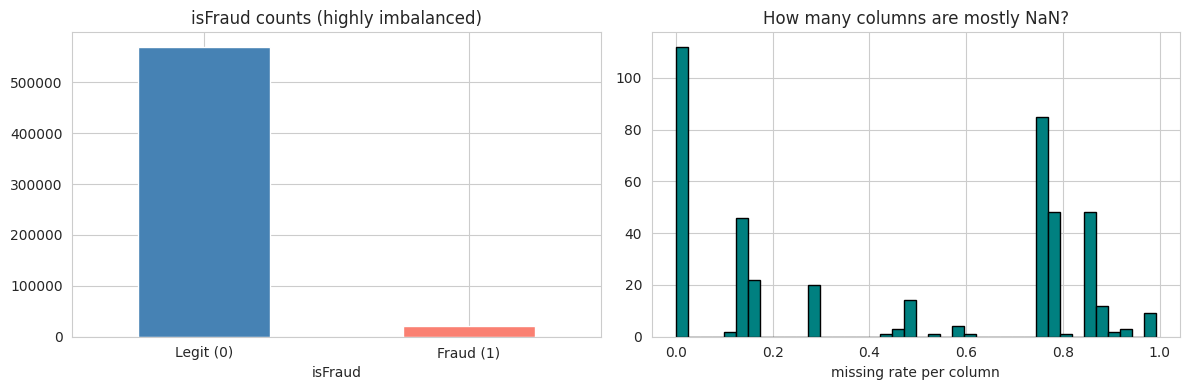


Columns with >50% missing values: 214  / 434
Columns with >90% missing values: 12


In [7]:
# Quick sanity check on class balance and missing rate.
print("Class distribution:")
print(train['isFraud'].value_counts(normalize=True).rename('pct'))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
train['isFraud'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue','salmon'])
ax[0].set_title('isFraud counts (highly imbalanced)')
ax[0].set_xticklabels(['Legit (0)','Fraud (1)'], rotation=0)

miss = train.isnull().mean().sort_values(ascending=False)
ax[1].hist(miss.values, bins=40, color='teal', edgecolor='black')
ax[1].set_xlabel('missing rate per column')
ax[1].set_title('How many columns are mostly NaN?')
plt.tight_layout(); plt.show()

print(f"\nColumns with >50% missing values: {(miss > 0.5).sum()}  / {train.shape[1]}")
print(f"Columns with >90% missing values: {(miss > 0.9).sum()}")


1. Cleaning

In [16]:
TARGET = "isFraud"
ID_COL = "TransactionID"

def analyse_missing(df, name):
    miss = df.isnull().mean().sort_values(ascending=False)
    almost_empty = miss[miss > 0.95].index.tolist()
    constant     = [c for c in df.columns
                    if df[c].nunique(dropna=False) <= 1]
    print(f"[{name}]  >95% NaN: {len(almost_empty)}   constant: {len(constant)}")
    return sorted(set(almost_empty + constant))

drop_train = analyse_missing(train, "train")
drop_test  = analyse_missing(test,  "test")
DROP_COLS = sorted(set(drop_train) | set(drop_test))
DROP_COLS = [c for c in DROP_COLS if c not in (TARGET, ID_COL)]

print(f"\nWill drop {len(DROP_COLS)} useless columns:")
print(DROP_COLS[:25], "...")

train.drop(columns=DROP_COLS, inplace=True, errors='ignore')
test.drop(columns=DROP_COLS,  inplace=True, errors='ignore')

print(f"\nAfter cleaning - train: {train.shape}, test: {test.shape}")
gc.collect()


[train]  >95% NaN: 9   constant: 0
[test]  >95% NaN: 9   constant: 1

Will drop 10 useless columns:
['V107', 'id_07', 'id_08', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27'] ...

After cleaning - train: (590540, 424), test: (506691, 423)


175

## 2. Feature Engineering

In [23]:
EMAIL_HIGH_RISK = {'protonmail.com','mail.com','outlook.es','aim.com',
                   'anonymous.com'}

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """All the engineered features (time, email, amount, aggregations)."""
    def __init__(self):
        self.card1_amt_mean_ = None
        self.card1_amt_std_  = None
        self.freq_maps_      = {}

    def fit(self, X, y=None):
        # Aggregations learned only on TRAIN
        if 'card1' in X.columns and 'TransactionAmt' in X.columns:
            g = X.groupby('card1')['TransactionAmt']
            self.card1_amt_mean_ = g.mean()
            self.card1_amt_std_  = g.std().fillna(0)
        for col in ['card1','card2','card3','card5','addr1','P_emaildomain',
                    'R_emaildomain']:
            if col in X.columns:
                self.freq_maps_[col] = X[col].value_counts(dropna=False)
        return self

    def transform(self, X):
        X = X.copy()
        # ---- time decomposition ----
        if 'TransactionDT' in X.columns:
            X['TX_hour']   = (X['TransactionDT'] // 3600) % 24
            X['TX_day']    = (X['TransactionDT'] // 86400)
            X['TX_dow']    = (X['TX_day'] % 7).astype('int8')
        # ---- amount features ----
        if 'TransactionAmt' in X.columns:
            X['TX_amt_log']     = np.log1p(X['TransactionAmt'])
            X['TX_amt_decimal'] = ((X['TransactionAmt'] -
                                    np.floor(X['TransactionAmt'])) * 1000).astype('int32')
        # ---- email features ----
        for col in ['P_emaildomain','R_emaildomain']:
            if col in X.columns:
                base = X[col].fillna('NA').astype(str)
                X[col + '_base'] = base.str.split('.').str[0]
                X[col + '_suf']  = base.str.split('.').str[-1]
                X[col + '_risk'] = base.isin(EMAIL_HIGH_RISK).astype('int8')
        # ---- card1 aggregations ----
        if self.card1_amt_mean_ is not None and 'card1' in X.columns:
            X['card1_amt_mean'] = X['card1'].map(self.card1_amt_mean_)
            X['card1_amt_std']  = X['card1'].map(self.card1_amt_std_)
            X['card1_amt_diff'] = X['TransactionAmt'] - X['card1_amt_mean']
        # ---- frequency encoding ----
        for col, fmap in self.freq_maps_.items():
            X[col + '_freq'] = X[col].map(fmap).fillna(0).astype('float32')
        return X


class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """Label-encode every object column the same way for train+test.
    Unknown test categories -> -1 (sentinel)."""
    def __init__(self):
        self.maps_ = {}

    def fit(self, X, y=None):
        for c in X.columns:
            if X[c].dtype == 'object' or X[c].dtype.name == 'category':
                vals = X[c].astype(str).fillna('NA').unique()
                self.maps_[c] = {v: i for i, v in enumerate(vals)}
        return self

    def transform(self, X):
        X = X.copy()
        for c, m in self.maps_.items():
            if c in X.columns:
                X[c] = X[c].astype(str).fillna('NA').map(m).fillna(-1).astype('int32')
        return X


class Imputer(BaseEstimator, TransformerMixin):
    """Median imputation for numeric, -1 for categorical/encoded.
    Also clips +-inf to NaN first so downstream models never see a non-finite value."""
    def __init__(self):
        self.medians_ = None

    def fit(self, X, y=None):
        Xc = X.replace([np.inf, -np.inf], np.nan)
        self.medians_ = Xc.median(numeric_only=True)
        return self

    def transform(self, X):
        X = X.copy()
        # Inf -> NaN first (e.g. card1_amt_diff after float32 downcast)
        X = X.replace([np.inf, -np.inf], np.nan)
        for c in X.columns:
            if X[c].isnull().any():
                X[c] = X[c].fillna(self.medians_.get(c, -1))
        # any remaining NaN (e.g. all-NaN col, object col) -> -1
        return X.fillna(-1)
        print(1)


In [20]:
# Build raw matrices we will pass through the FE pipeline
y          = train[TARGET].values
X_train_raw = train.drop(columns=[TARGET, ID_COL])
X_test_raw  = test.drop(columns=[ID_COL])
print(f"Raw shapes: train {X_train_raw.shape}, test {X_test_raw.shape}")

fe_pipeline = Pipeline([
    ('feat',    FeatureEngineer()),
    ('catenc',  CategoricalEncoder()),
    ('impute',  Imputer()),
])

fe_pipeline.fit(X_train_raw, y)
X_train_fe = fe_pipeline.transform(X_train_raw)
X_test_fe  = fe_pipeline.transform(X_test_raw)
print(f"After FE  : train {X_train_fe.shape}, test {X_test_fe.shape}")

# Hard sanity: nothing non-finite reaches feature selection / models.
# (mutual_info_classif and VarianceThreshold both call check_array with
#  force_all_finite=True and will raise ValueError otherwise.)
def assert_finite(df, name):
    nans = int(df.isnull().sum().sum())
    infs = int(np.isinf(df.select_dtypes(include=[np.number]).values).sum())
    print(f"  [{name}] NaNs={nans}, Infs={infs}")
    if nans or infs:
        # belt-and-braces: replace and continue
        df.replace([np.inf, -np.inf], 0, inplace=True)
        df.fillna(0, inplace=True)
        print(f"  [{name}] -> cleaned to all-finite")
    return df

X_train_fe = assert_finite(X_train_fe, 'train_fe')
X_test_fe  = assert_finite(X_test_fe,  'test_fe')


Raw shapes: train (590540, 422), test (506691, 422)
After FE  : train (590540, 443), test (506691, 443)
  [train_fe] NaNs=0, Infs=0
  [test_fe] NaNs=0, Infs=0


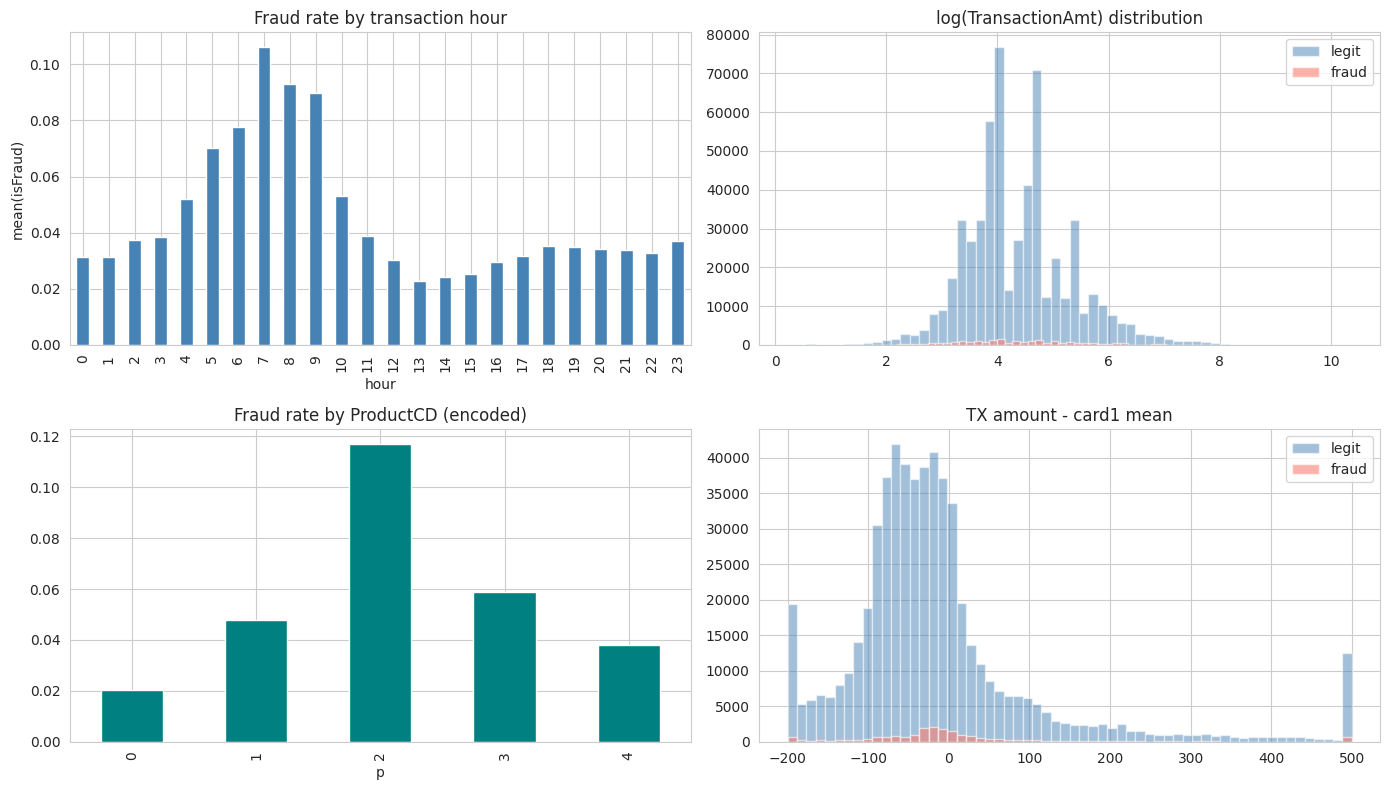

In [25]:
# Visualise a few engineered features vs target
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

# fraud rate by hour
hr = pd.DataFrame({'hour': X_train_fe['TX_hour'], 'fraud': y})
hr.groupby('hour')['fraud'].mean().plot(kind='bar', ax=ax[0,0], color='steelblue')
ax[0,0].set_title('Fraud rate by transaction hour')
ax[0,0].set_ylabel('mean(isFraud)')

# log amount distribution
ax[0,1].hist(X_train_fe.loc[y==0,'TX_amt_log'], bins=60, alpha=.5, label='legit', color='steelblue')
ax[0,1].hist(X_train_fe.loc[y==1,'TX_amt_log'], bins=60, alpha=.6, label='fraud', color='salmon')
ax[0,1].legend(); ax[0,1].set_title('log(TransactionAmt) distribution')

# fraud rate by ProductCD if encoded
if 'ProductCD' in X_train_fe.columns:
    pcd = pd.DataFrame({'p': X_train_fe['ProductCD'], 'fraud': y})
    pcd.groupby('p')['fraud'].mean().plot(kind='bar', ax=ax[1,0], color='teal')
    ax[1,0].set_title('Fraud rate by ProductCD (encoded)')

# card1_amt_diff for fraud vs legit
if 'card1_amt_diff' in X_train_fe.columns:
    ax[1,1].hist(X_train_fe.loc[y==0,'card1_amt_diff'].clip(-200,500), bins=60,
                 alpha=.5, label='legit', color='steelblue')
    ax[1,1].hist(X_train_fe.loc[y==1,'card1_amt_diff'].clip(-200,500), bins=60,
                 alpha=.6, label='fraud', color='salmon')
    ax[1,1].legend(); ax[1,1].set_title('TX amount - card1 mean')

plt.tight_layout(); plt.show()




3. Feature Selection



VarianceThreshold:  kept 419 / 443 columns
Correlation filter (>0.95): dropped 111,  kept 308


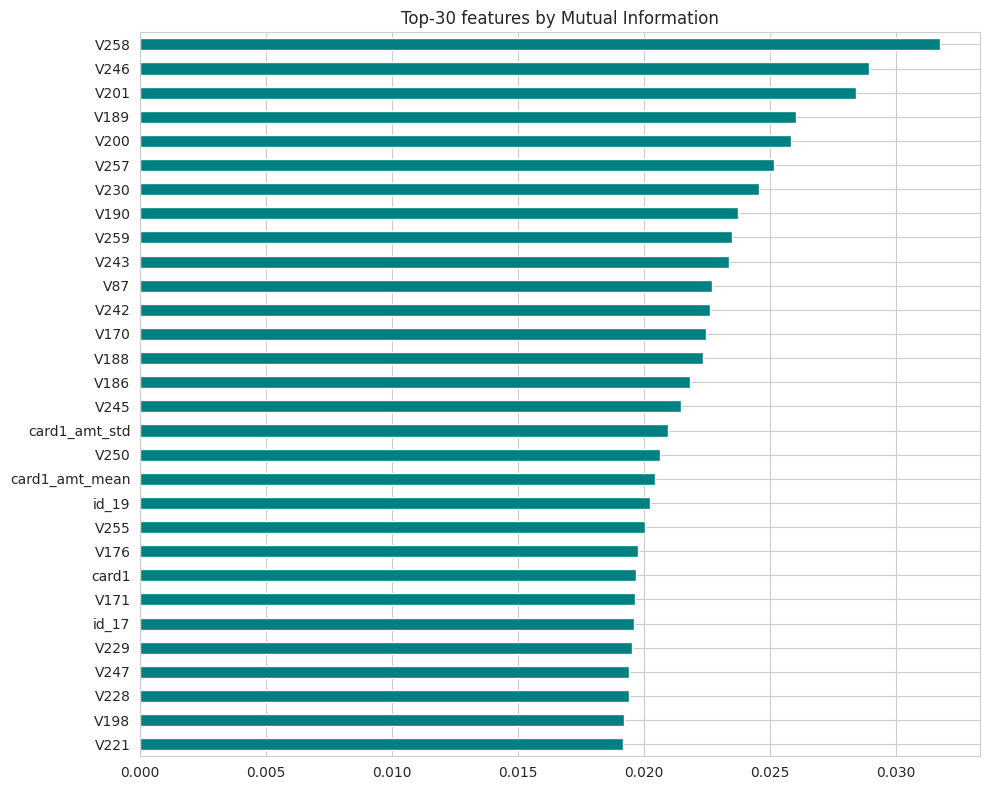


MI top-60 kept.
  all_after_VT         -> 419 features
  corr_filter_0.95     -> 308 features
  MI_top60             -> 60 features


In [26]:
# 3.1 Variance threshold (drop near-constant)
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_fe)
keep_vt = X_train_fe.columns[vt.get_support()]
print(f"VarianceThreshold:  kept {len(keep_vt)} / {X_train_fe.shape[1]} columns")

# 3.2 Correlation filter
def corr_filter(df, thr=0.95):
    cm = df.corr().abs()
    upper = cm.where(np.triu(np.ones(cm.shape), 1).astype(bool))
    drop = [c for c in upper.columns if (upper[c] > thr).any()]
    return drop
drop_corr = corr_filter(X_train_fe[keep_vt], thr=0.95)
keep_corr = [c for c in keep_vt if c not in drop_corr]
print(f"Correlation filter (>0.95): dropped {len(drop_corr)},  kept {len(keep_corr)}")

# 3.3 Mutual information (sample for speed)
sample_idx = np.random.RandomState(SEED).choice(len(X_train_fe),
                                                size=min(50000, len(X_train_fe)),
                                                replace=False)
mi = mutual_info_classif(X_train_fe.iloc[sample_idx][keep_corr],
                         y[sample_idx], random_state=SEED)
mi_series = pd.Series(mi, index=keep_corr).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
mi_series.head(30).plot(kind='barh', ax=ax, color='teal')
ax.invert_yaxis(); ax.set_title('Top-30 features by Mutual Information')
plt.tight_layout(); plt.show()

TOPK = 60
keep_mi = mi_series.head(TOPK).index.tolist()
print(f"\nMI top-{TOPK} kept.")

FEATURE_SETS = {
    'all_after_VT'     : list(keep_vt),
    'corr_filter_0.95' : keep_corr,
    f'MI_top{TOPK}'    : keep_mi,
}
for name, cols in FEATURE_SETS.items():
    print(f"  {name:20s} -> {len(cols)} features")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  all_after_VT         |  419 feats | AUC = 0.85833 (+/- 0.00386)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  corr_filter_0.95     |  308 feats | AUC = 0.85639 (+/- 0.00307)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  MI_top60             |   60 feats | AUC = 0.78648 (+/- 0.00232)

Best FS = all_after_VT  (419 features)


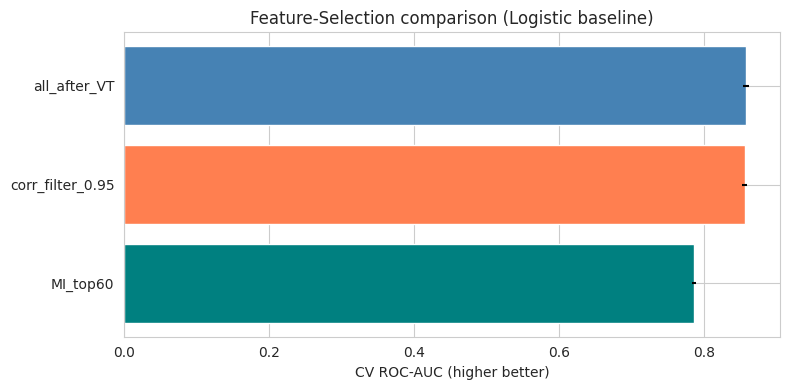

In [27]:
# Compare each feature set with a quick logistic regression CV
from sklearn.linear_model import LogisticRegression as _Quick
quick = _Quick(max_iter=200, n_jobs=-1, solver='lbfgs')
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

fs_results = []
for name, cols in FEATURE_SETS.items():
    Xs = X_train_fe[cols].values
    Xs = StandardScaler(with_mean=False).fit_transform(Xs)
    aucs = cross_val_score(quick, Xs, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    fs_results.append({'method': name, 'n_feat': len(cols),
                       'mean_auc': aucs.mean(), 'std_auc': aucs.std()})
    print(f"  {name:20s} | {len(cols):4d} feats | AUC = {aucs.mean():.5f} (+/- {aucs.std():.5f})")

fs_df = pd.DataFrame(fs_results).sort_values('mean_auc', ascending=False)
best_fs_name = fs_df.iloc[0]['method']
SELECTED_FEATURES = FEATURE_SETS[best_fs_name]
print(f"\nBest FS = {best_fs_name}  ({len(SELECTED_FEATURES)} features)")

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(fs_df['method'], fs_df['mean_auc'], xerr=fs_df['std_auc'],
        color=['steelblue','coral','teal'])
ax.set_xlabel('CV ROC-AUC (higher better)'); ax.invert_yaxis()
ax.set_title('Feature-Selection comparison (Logistic baseline)')
plt.tight_layout(); plt.show()



4. Training - Linear Regression (regression-on-binary baseline)


In [28]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_sel = X_train_fe[SELECTED_FEATURES].astype(np.float32).values
X_tr, X_val, y_tr, y_val = train_test_split(X_sel, y, test_size=0.2,
                                            stratify=y, random_state=SEED)
scaler = StandardScaler(with_mean=False)
X_tr_s, X_val_s = scaler.fit_transform(X_tr), scaler.transform(X_val)

def lin_fit_eval(model, X_tr, y_tr, X_val, y_val, cv=None):
    model.fit(X_tr, y_tr)
    p_tr  = model.predict(X_tr)
    p_val = model.predict(X_val)
    return {
        'train_auc'  : roc_auc_score(y_tr,  p_tr),
        'val_auc'    : roc_auc_score(y_val, p_val),
        'train_ap'   : average_precision_score(y_tr,  p_tr),
        'val_ap'     : average_precision_score(y_val, p_val),
        'overfit_gap': roc_auc_score(y_tr, p_tr) - roc_auc_score(y_val, p_val),
    }

results_log = []


In [29]:
m = LinearRegression(n_jobs=-1)
mt = lin_fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print("OLS:", mt)
results_log.append({'name': "OLS", 'model': m, **mt})


OLS: {'train_auc': np.float64(0.8345459941835972), 'val_auc': np.float64(0.8329803192776356), 'train_ap': np.float64(0.3911070037558273), 'val_ap': np.float64(0.39698278195754966), 'overfit_gap': np.float64(0.0015656749059616004)}


In [30]:
m = Ridge(alpha=1.0)
mt = lin_fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print("Ridge a=1.0:", mt)
results_log.append({'name': "Ridge a=1.0", 'model': m, **mt})


Ridge a=1.0: {'train_auc': np.float64(0.8473300777409145), 'val_auc': np.float64(0.8427834685349971), 'train_ap': np.float64(0.42188879566629367), 'val_ap': np.float64(0.4229180336166275), 'overfit_gap': np.float64(0.004546609205917429)}


In [31]:
m = Ridge(alpha=10.0)
mt = lin_fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print("Ridge a=10.0:", mt)
results_log.append({'name': "Ridge a=10.0", 'model': m, **mt})


Ridge a=10.0: {'train_auc': np.float64(0.8471554288541592), 'val_auc': np.float64(0.8424953918957123), 'train_ap': np.float64(0.4217132324894671), 'val_ap': np.float64(0.42299039755313644), 'overfit_gap': np.float64(0.004660036958446856)}


In [32]:
m = Ridge(alpha=100.0)
mt = lin_fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print("Ridge a=100:", mt)
results_log.append({'name': "Ridge a=100", 'model': m, **mt})


Ridge a=100: {'train_auc': np.float64(0.8471654654647218), 'val_auc': np.float64(0.8425155475589107), 'train_ap': np.float64(0.42122830099646524), 'val_ap': np.float64(0.42233574726825707), 'overfit_gap': np.float64(0.004649917905811152)}


In [33]:
m = Lasso(alpha=1e-4, max_iter=10000)
mt = lin_fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print("Lasso a=1e-4:", mt)
results_log.append({'name': "Lasso a=1e-4", 'model': m, **mt})


Lasso a=1e-4: {'train_auc': np.float64(0.8464039909735007), 'val_auc': np.float64(0.8419859235157914), 'train_ap': np.float64(0.41579300383547846), 'val_ap': np.float64(0.418376476617515), 'overfit_gap': np.float64(0.00441806745770934)}


In [34]:
m = Lasso(alpha=1e-3, max_iter=10000)
mt = lin_fit_eval(m, X_tr_s, y_tr, X_val_s, y_val)
print("Lasso a=1e-3:", mt)
results_log.append({'name': "Lasso a=1e-3", 'model': m, **mt})


Lasso a=1e-3: {'train_auc': np.float64(0.8328002162312915), 'val_auc': np.float64(0.8331149999519698), 'train_ap': np.float64(0.38728092387765), 'val_ap': np.float64(0.39389946358747147), 'overfit_gap': np.float64(-0.00031478372067828)}


        name  train_auc  val_auc   val_ap  overfit_gap diagnosis
 Ridge a=1.0   0.847330 0.842783 0.422918     0.004547        ok
 Ridge a=100   0.847165 0.842516 0.422336     0.004650        ok
Ridge a=10.0   0.847155 0.842495 0.422990     0.004660        ok
Lasso a=1e-4   0.846404 0.841986 0.418376     0.004418        ok
Lasso a=1e-3   0.832800 0.833115 0.393899    -0.000315 lucky-val
         OLS   0.834546 0.832980 0.396983     0.001566        ok


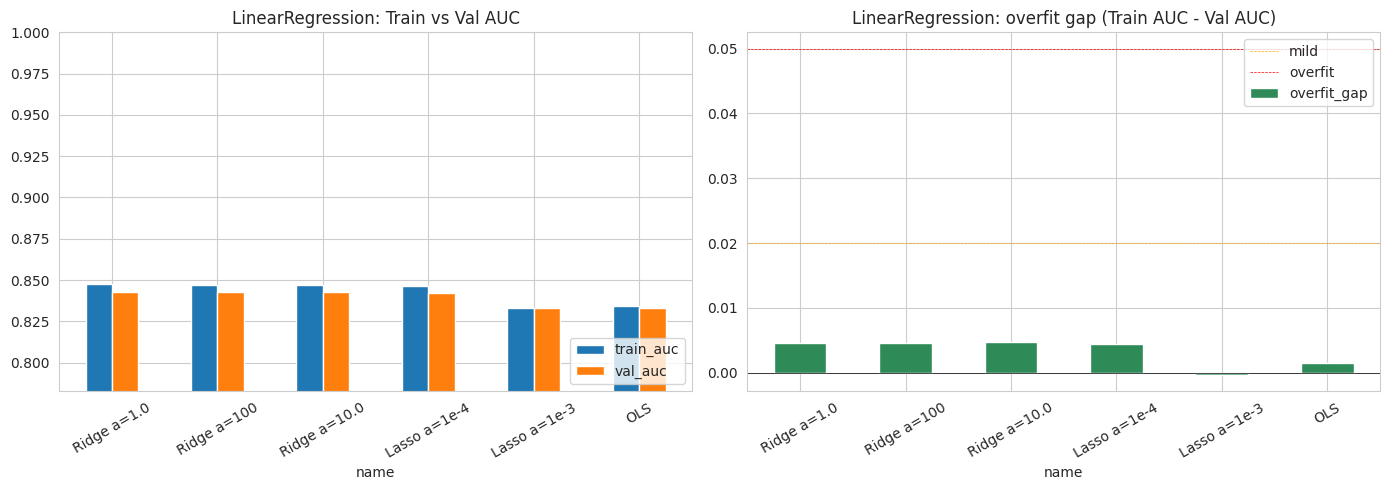

-> picked best_model = Ridge a=1.0


In [38]:
df_results = pd.DataFrame([{k:v for k,v in r.items() if k!='model'} for r in results_log])
df_results = df_results.sort_values('val_auc', ascending=False).reset_index(drop=True)


def _diag(row):
    if row['train_auc'] < 0.75:
        return 'UNDERFIT'
    if row['overfit_gap'] > 0.05:
        return 'OVERFIT'
    if row['overfit_gap'] < 0:
        return 'lucky-val'
    if row['val_auc'] >= 0.85 and row['overfit_gap'] <= 0.02:
        return 'HEALTHY'
    return 'mild-overfit' if row['overfit_gap'] > 0.02 else 'ok'
df_results['diagnosis'] = df_results.apply(_diag, axis=1)

_default_cols = ['name','train_auc','val_auc','val_f1','val_ap','overfit_gap','diagnosis']
show_cols = [c for c in _default_cols if c in df_results.columns]
print(df_results[show_cols].to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df_results.set_index('name')[['train_auc','val_auc']].plot(kind='bar', ax=ax[0])
ax[0].set_title('LinearRegression: Train vs Val AUC')
ax[0].set_ylim(max(0.5, df_results[['train_auc','val_auc']].min().min()-0.05), 1.0)
ax[0].tick_params(axis='x', rotation=30); ax[0].legend(loc='lower right')

colors = ['salmon' if g > 0.05 else ('orange' if g > 0.02 else 'seagreen')
          for g in df_results['overfit_gap']]
df_results.set_index('name')['overfit_gap'].plot(kind='bar', ax=ax[1], color=colors)
ax[1].axhline(0,    color='black', lw=0.5)
ax[1].axhline(0.02, color='orange', ls='--', lw=0.5, label='mild')
ax[1].axhline(0.05, color='red',    ls='--', lw=0.5, label='overfit')
ax[1].set_title('LinearRegression: overfit gap (Train AUC - Val AUC)')
ax[1].tick_params(axis='x', rotation=30); ax[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

n_over   = int((df_results['diagnosis']=='OVERFIT').sum())
n_under  = int((df_results['diagnosis']=='UNDERFIT').sum())
n_health = int((df_results['diagnosis']=='HEALTHY').sum())
best     = df_results.iloc[0]
worst    = df_results.iloc[-1]

best_model = [r['model'] for r in results_log if r['name']==best['name']][0]
print(f"-> picked best_model = {best['name']}")


5. Pipeline Construction & Save




In [42]:
import pickle
from sklearn.pipeline import Pipeline

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X[self.cols]

# Build a single pipeline that runs on RAW test data
final_pipeline = Pipeline([
    ('feat',   FeatureEngineer()),
    ('catenc', CategoricalEncoder()),
    ('impute', Imputer()),
    ('select', ColumnSelector(SELECTED_FEATURES)),
    ('model',  best_model),
])

# Refit FE part + best model on the FULL training data (raw)
final_pipeline.fit(X_train_raw, y)
print("Pipeline fitted on full raw training data.")

if hasattr(final_pipeline, 'predict_proba'):
    test_pred_proba = final_pipeline.predict_proba(X_test_raw)[:, 1]
else:
    test_pred_proba = final_pipeline.predict(X_test_raw)
print(f"Test prediction sample: {test_pred_proba[:5]}")
print(f"Mean predicted score  : {test_pred_proba.mean():.4f}")

# Save pipeline locally too (optional)
PIPE_PATH = f"pipeline_{MODEL_TAG}.pkl"
with open(PIPE_PATH, 'wb') as f:
    pickle.dump(final_pipeline, f)
print(f"Pipeline saved to {PIPE_PATH}")


Pipeline fitted on full raw training data.
Test prediction sample: [0.01418659 0.03137676 0.01711903 0.03664961 0.0098991 ]
Mean predicted score  : 0.0502
Pipeline saved to pipeline_LinearRegression.pkl


6. MLflow Logging


In [52]:
# 6.3  Cleaning summary run
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Cleaning"):
    mlflow.log_param('stage', 'cleaning')
    mlflow.log_param('dropped_columns', len(DROP_COLS))
    mlflow.log_param('train_shape_after', str(train.shape))
    mlflow.log_param('test_shape_after',  str(test.shape))
print("Cleaning run logged.")


🏃 View run LinearRegression_Cleaning at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2/runs/0475052f7afc47849d929eac678ebaf4
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2
Cleaning run logged.


In [51]:
# 6.2  Feature-Selection comparison run
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Feature_Selection"):
    mlflow.log_param('stage', 'feature_selection')
    mlflow.log_param('chosen', best_fs_name if 'best_fs_name' in dir() else 'n/a')
    mlflow.log_param('n_selected', len(SELECTED_FEATURES))
    if 'fs_df' in dir():
        for _, row in fs_df.iterrows():
            mlflow.log_metric(f"AUC_{row['method']}", float(row['mean_auc']))
print("Feature Selection run logged.")


🏃 View run LinearRegression_Feature_Selection at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2/runs/d403dd86ff464447afcc331bf586a652
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2
Feature Selection run logged.


In [50]:
# 6.1  Per-hyperparameter runs
mlflow.set_experiment(MLFLOW_EXPERIMENT)

for r in results_log:
    with mlflow.start_run(run_name=r['name']):
        # Params (model + general)
        mlflow.log_param('model_type',        MODEL_TAG)
        mlflow.log_param('n_features',        len(SELECTED_FEATURES))
        mlflow.log_param('feature_selection', best_fs_name if 'best_fs_name' in dir() else 'manual')
        mlflow.log_param('config',            r['name'])
        # Metrics
        for k, v in r.items():
            if k in ('name','model'): continue
            try: mlflow.log_metric(k, float(v))
            except Exception: pass
print("Logged all training runs to MLflow.")


2026/05/04 02:11:54 INFO mlflow.tracking.fluent: Experiment with name 'LinearRegressionTraining' does not exist. Creating a new experiment.


🏃 View run OLS at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2/runs/867340141e5e459e9272aa0ab715e157
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2
🏃 View run Ridge a=1.0 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2/runs/faa5bce75b1e4336a0e99c47896875d0
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2
🏃 View run Ridge a=10.0 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2/runs/5479e7812893499dac4bc0fc0ebeee71
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2
🏃 View run Ridge a=100 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2/runs/79380115322c47debc2836825ee796b1
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2
🏃 View run Lasso a=1e-4 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2/runs/faae6acded174412a74aa05847a8a5d7
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/exper

In [53]:
# 6.4  Cross-validation run for the BEST hyperparameter set
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print("Re-running 5-fold CV for the BEST config ")

# Custom AUC scorer that works for classifiers AND regression baselines.
# (Ridge / Lasso / LinearRegression have no predict_proba; AUC is rank-based,
#  so predict() output works fine as a ranking score.)
from sklearn.metrics import roc_auc_score
def _auc_scorer(estimator, X, y_true):
    if hasattr(estimator, 'predict_proba'):
        s = estimator.predict_proba(X)[:, 1]
    elif hasattr(estimator, 'decision_function'):
        s = estimator.decision_function(X)
    else:
        s = estimator.predict(X)
    return roc_auc_score(y_true, s)

cv5_aucs = cross_val_score(best_model, X_train_fe[SELECTED_FEATURES].values, y,
                           cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                           scoring=_auc_scorer, n_jobs=-1)
print(f"CV AUC mean = {cv5_aucs.mean():.5f} +/- {cv5_aucs.std():.5f}")

with mlflow.start_run(run_name=f"{MODEL_TAG}_CrossValidation"):
    mlflow.log_param('stage', 'cross_validation')
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('best_config', best['name'])
    mlflow.log_metric('cv_auc_mean', float(cv5_aucs.mean()))
    mlflow.log_metric('cv_auc_std',  float(cv5_aucs.std()))
    for i, a in enumerate(cv5_aucs):
        mlflow.log_metric(f'cv_auc_fold{i+1}', float(a))
print("Cross-validation run logged.")

Re-running 5-fold CV for the BEST config 


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.83399e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.83569e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.84608e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.84148e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.8413e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


CV AUC mean = 0.84494 +/- 0.00400
🏃 View run LinearRegression_CrossValidation at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2/runs/9b6d6b380f8448e1993dee6d2b9d4d1d
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2
Cross-validation run logged.


In [54]:
# 6.5  FINAL run -- log the trained Pipeline as MLflow artifact
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Final_Pipeline"):
    mlflow.log_param('model_type',        MODEL_TAG)
    mlflow.log_param('best_config',       best['name'])
    mlflow.log_param('n_features',        len(SELECTED_FEATURES))
    mlflow.log_param('feature_selection', best_fs_name if 'best_fs_name' in dir() else 'manual')

    mlflow.log_metric('best_val_auc',     float(best['val_auc']))
    mlflow.log_metric('best_train_auc',   float(best['train_auc']))
    mlflow.log_metric('best_overfit_gap', float(best['overfit_gap']))
    if 'cv5_aucs' in dir():
        mlflow.log_metric('cv_auc_mean', float(cv5_aucs.mean()))

    # Log entire pipeline (preprocessing + model) as an MLflow sklearn model
    # so model_inference can load it from the registry directly.
    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path='model',
        registered_model_name=f'IEEE_Fraud_{MODEL_TAG}',
    )

print(f"Final pipeline logged & registered as 'IEEE_Fraud_{MODEL_TAG}'.")
print(f"    mlflow.sklearn.load_model('models:/IEEE_Fraud_{MODEL_TAG}/latest')")


2026/05/04 02:14:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 02:14:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'IEEE_Fraud_LinearRegression'.
2026/05/04 02:14:47 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: IEEE_Fraud_LinearRegression, version 1
Created version '1' of model 'IEEE_Fraud_LinearRegression'.


🏃 View run LinearRegression_Final_Pipeline at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2/runs/7b887a3f14a84c2b83e1f412394d9092
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/2
Final pipeline logged & registered as 'IEEE_Fraud_LinearRegression'.
In model_inference.ipynb you can now load it via:
    mlflow.sklearn.load_model('models:/IEEE_Fraud_LinearRegression/latest')
